[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-nirspec-spectral-atlas/notebook.ipynb)

# Real HST images and JWST spectra of distant galaxies

**Scientific question:** What do the calibrated 1D and 2D NIRSpec data look like for six z=7.88 to 13.16 galaxies?


This notebook is an independent audit of public UNCOVER DR4.1 spectroscopy in
the Abell 2744 field. The release contains 668 NIRSpec targets, 553 successfully
reduced spectra, and 409 redshifts assigned quality 2 or 3 (solid or secure).
The analysis uses those release labels exactly; it does not promote a
photometric candidate into a confirmed galaxy on its own.

## What is measured and what is not

The DR3 catalogue supplied broad-band photometric redshifts. DR4.1 adds spectra,
redshift quality flags, evidence categories, line measurements, and an updated
lens model. Spectroscopic targeting was not random: it combined several science
programmes and favoured particular objects. Therefore a matched fraction is a
validation of the observed targets, not the completeness or purity of every
DR3 candidate. A non-match means “not tested here,” not “false.”

Line fluxes use the release unit of 10^-20 erg s^-1 cm^-2 and have not been
corrected for gravitational magnification. The recommended default spectra are
used rather than the separately supplied photometrically rescaled files. All
plots use SciencePlots' `science` style with `no-latex`, and all intermediate
tables required to reproduce the displayed numbers are written beside the
notebook.

## Reproducibility and claim boundary

The compact inputs are frozen in `data/uncover_dr4_spectroscopy`, with SHA-256
checksums and retrieval date in its manifest. The authoritative source is the
UNCOVER DR4.1 release page and Price et al. (2025). The results below describe
this public release. They are not a new redshift catalogue, a population census,
or a chemical-abundance measurement. Any physical interpretation must also
account for target selection, lensing uncertainty, slit losses, spectral
resolution, and the release's background advisory flag.

## Analysis plan

This atlas opens six original DR4.1 FITS spectra and plots the calibrated 1D
flux together with the real 2D detector cutout. The wavelength axis is also
translated to rest frame using the catalogue redshift. A companion figure uses
HST Frontier Fields F105W, F125W, and F160W cutouts returned by the MAST Astrocut
service. At these redshifts an HST non-detection can be physically expected;
the cutouts are included as data, not enhanced into a false visible source.

The vertical Lyman-alpha marker is a wavelength reference, not a claim that an
emission line is detected. Real slit spectra contain noise, residuals, and
contamination, so the 2D panel is essential evidence beside the extracted 1D
curve.

In [1]:
from pathlib import Path
import json, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.ndimage import gaussian_filter
from astropy.io import fits

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/uncover_dr4_spectroscopy")
if not DATA.exists(): DATA=Path("data/uncover_dr4_spectroscopy")

In [2]:
cross=pd.read_csv(DATA/"dr3_dr4_highz_crossmatch.csv")
cross["z_spec"]=cross["z_spec_dr4"]
secure=pd.read_csv(DATA/"dr4_secure_redshifts.csv")
lines=pd.read_csv(DATA/"dr4_highz_line_fluxes.csv")
mag=pd.read_csv(DATA/"dr4_highz_magnifications.csv")
print(f"DR3 high-z candidates with solid/secure DR4.1 matches: {len(cross)}")
print(f"All solid/secure DR4.1 redshifts: {len(secure)}; z>=6: {(secure.z_spec>=6).sum()}")

DR3 high-z candidates with solid/secure DR4.1 matches: 44
All solid/secure DR4.1 redshifts: 409; z>=6: 48


In [3]:
meta=secure[secure.id_msa.isin([3686,10646,13077,22223,26185,60157])][["id_msa","z_spec","ra","dec","flag_zspec_qual"]].sort_values("z_spec")
meta.to_csv("spectral_atlas_sources.csv",index=False); print(meta.to_string(index=False))
specfiles={int(p.stem.split("_")[-1].split(".")[0]):p for p in (DATA/"spectra").glob("*.fits")}

 id_msa    z_spec       ra        dec  flag_zspec_qual
  60157  7.880038 3.603847 -30.382238                3
  10646  8.510590 3.636960 -30.406362                3
   3686  9.318165 3.617202 -30.425534                3
  22223  9.569852 3.568115 -30.383052                3
  26185 10.060783 3.567071 -30.377861                3
  13077 13.163633 3.570869 -30.401585                2


## Primary evidence

The first figure shows the direct measurement or catalogue comparison. Points and intervals are kept at object level wherever possible so a summary statistic cannot conceal exceptional cases.

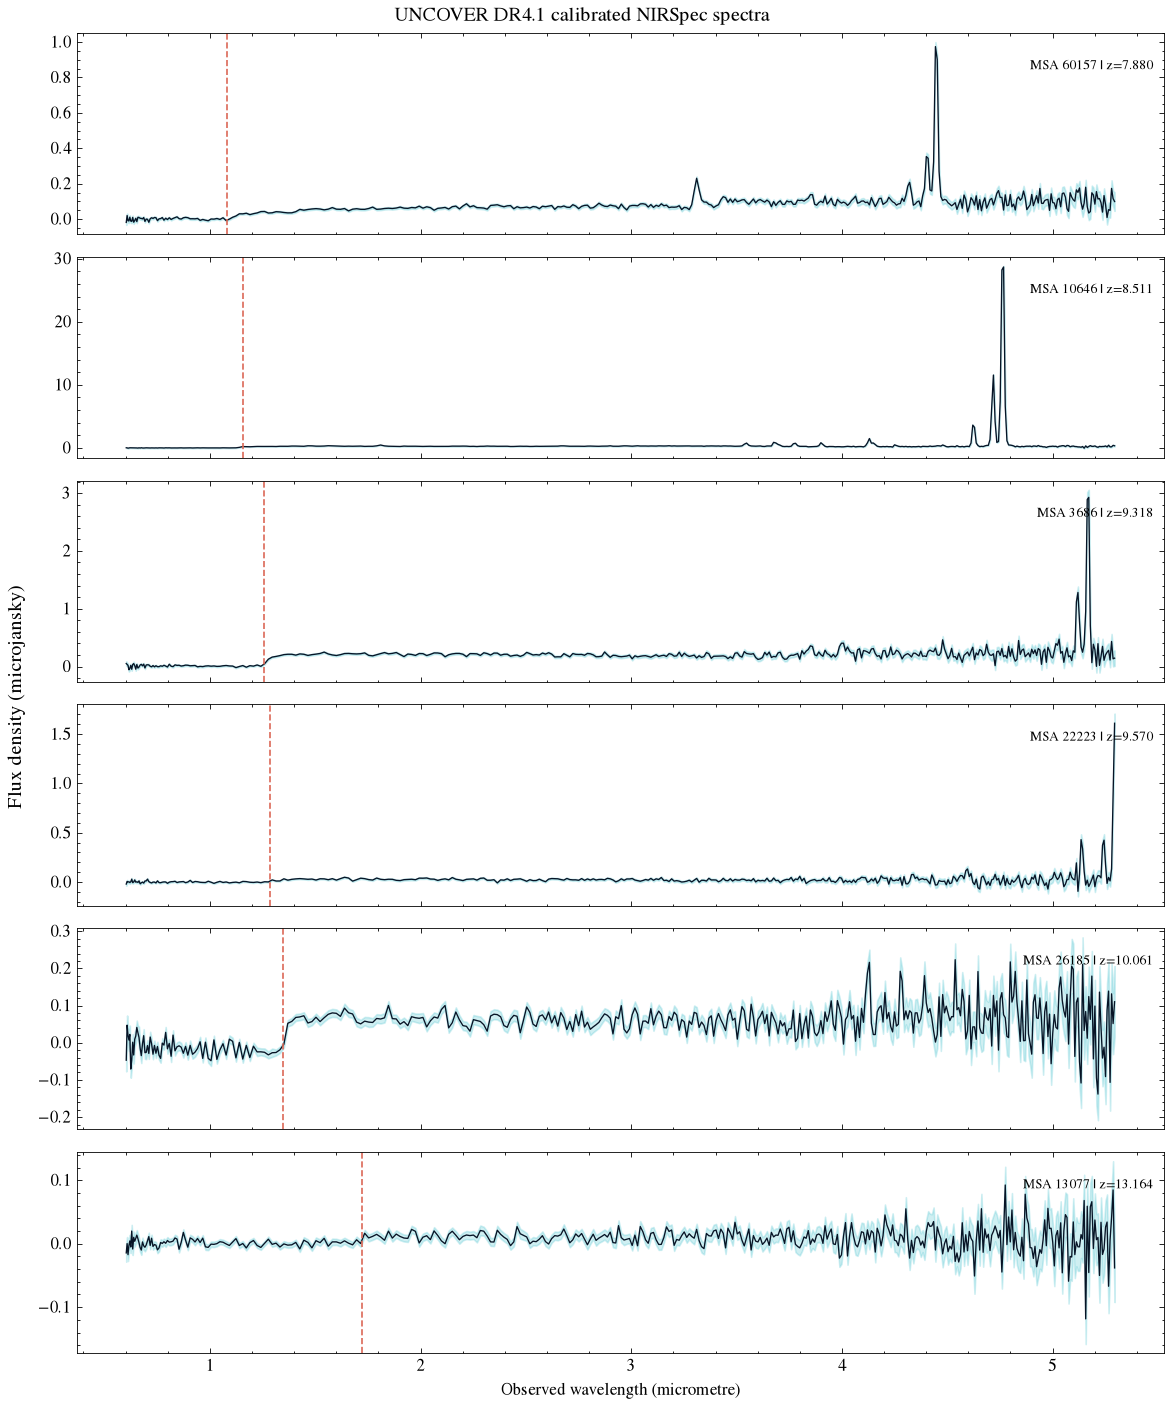

In [4]:
fig,axes=plt.subplots(len(meta),1,figsize=(10,12),sharex=True)
for ax,(_,row) in zip(axes,meta.iterrows()):
 with fits.open(specfiles[int(row.id_msa)]) as h: d=h["SPEC1D"].data; w=np.asarray(d["wave"]); f=np.asarray(d["flux"]); e=np.asarray(d["err"])
 good=np.isfinite(w)&np.isfinite(f)&np.isfinite(e)&(e>0); ax.plot(w[good],f[good],color=COLORS["navy"],lw=.8); ax.fill_between(w[good],f[good]-e[good],f[good]+e[good],color=COLORS["cyan"],alpha=.22)
 ax.axvline(.1216*(1+row.z_spec),color=COLORS["coral"],ls="--",lw=1); ax.text(.99,.82,f"MSA {int(row.id_msa)} | z={row.z_spec:.3f}",transform=ax.transAxes,ha="right",fontsize=8)
axes[-1].set(xlabel="Observed wavelength (micrometre)"); fig.supylabel("Flux density (microjansky)"); fig.suptitle("UNCOVER DR4.1 calibrated NIRSpec spectra")
fig.tight_layout(); fig.savefig("nirspec_1d_atlas.png"); plt.show()

## Independent view or stress test

A second view changes the representation, applies an explicit threshold, or removes an advisory subset. Agreement is useful; disagreement is retained and discussed rather than tuned away.

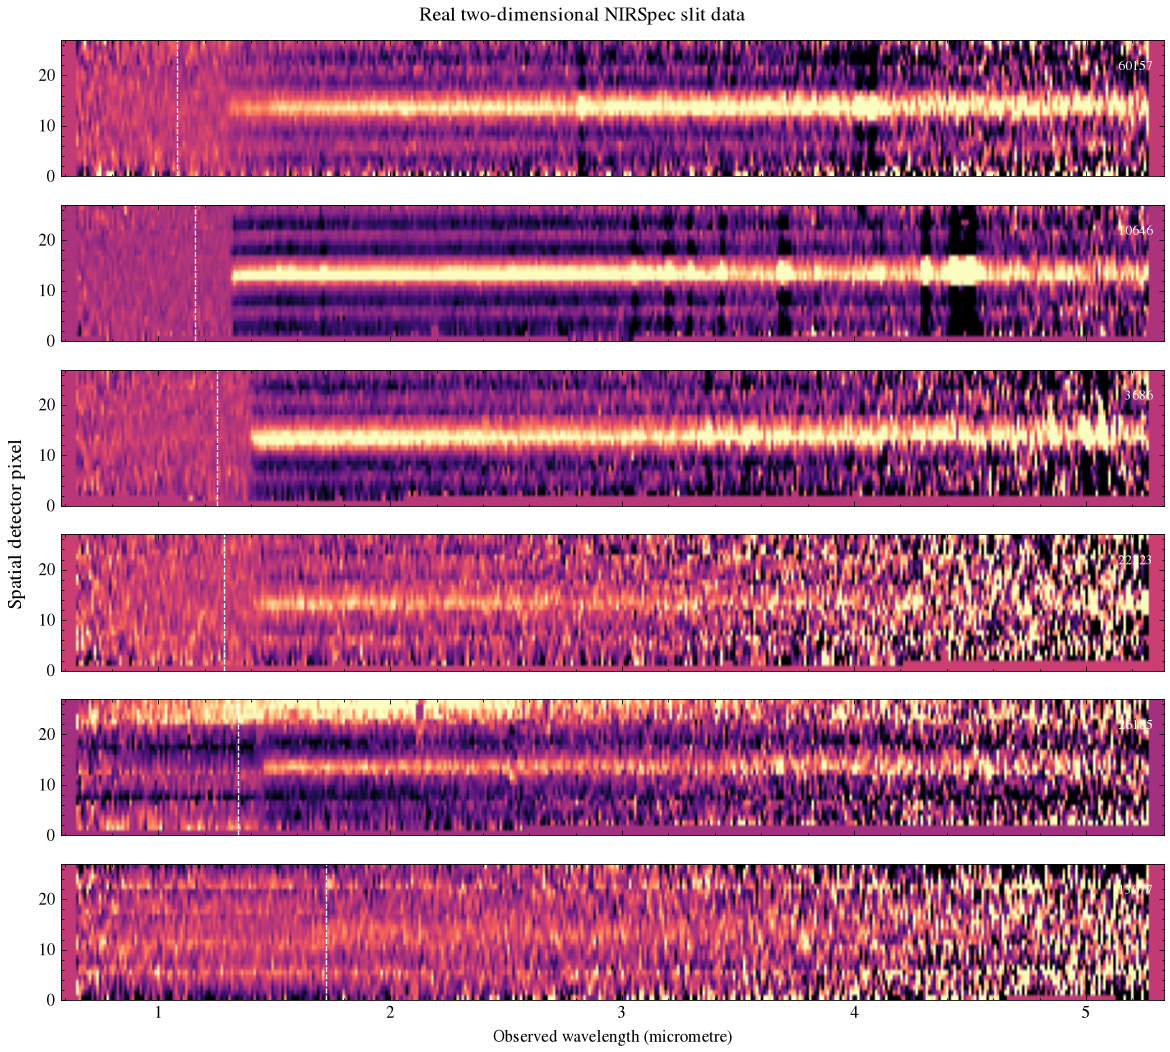

In [5]:
fig,axes=plt.subplots(len(meta),1,figsize=(10,9),sharex=True)
for ax,(_,row) in zip(axes,meta.iterrows()):
 with fits.open(specfiles[int(row.id_msa)]) as h: im=np.asarray(h["SCI"].data); w=np.asarray(h["SPEC1D"].data["wave"])
 finite=im[np.isfinite(im)]; lo,hi=np.nanpercentile(finite,[5,95]); ax.imshow(im,origin="lower",aspect="auto",extent=[w.min(),w.max(),0,im.shape[0]],cmap="magma",vmin=lo,vmax=hi)
 ax.axvline(.1216*(1+row.z_spec),color="white",ls="--",lw=.8); ax.text(.99,.78,f"{int(row.id_msa)}",color="white",transform=ax.transAxes,ha="right",fontsize=8)
axes[-1].set(xlabel="Observed wavelength (micrometre)"); fig.supylabel("Spatial detector pixel"); fig.suptitle("Real two-dimensional NIRSpec slit data")
fig.tight_layout(); fig.savefig("nirspec_2d_atlas.png"); plt.show()

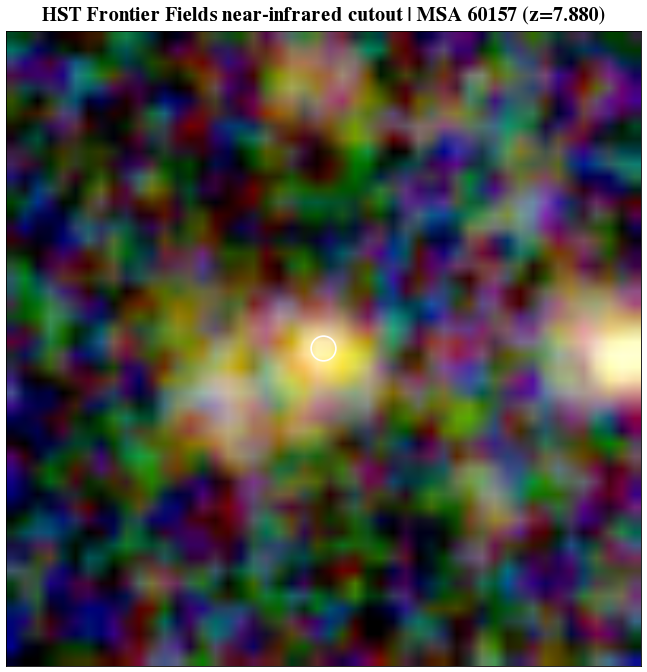

In [6]:
cutzip=DATA/"cutouts/hst_60157_astrocut.zip"; channels={}
with zipfile.ZipFile(cutzip) as z:
 name=z.namelist()[0]
 with z.open(name) as stream, fits.open(stream) as h:
  for ext in h[1:]:
   filt=ext.header.get("FILTER")
   if filt in {"F105W","F125W","F160W"}: channels[filt]=np.asarray(ext.data,float)
rgb=[]
for filt in ["F160W","F125W","F105W"]:
 a=gaussian_filter(channels[filt],.6); med=np.nanmedian(a); sig=1.4826*np.nanmedian(np.abs(a-med)); rgb.append(np.arcsinh(6*np.clip((a-(med-sig))/(10*sig),0,1))/np.arcsinh(6))
rgb=np.dstack(rgb); pd.DataFrame({"filter":["F105W","F125W","F160W"],"role":["blue","green","red"]}).to_csv("hst_rgb_channels.csv",index=False)
fig,ax=plt.subplots(figsize=(5.8,5.8)); ax.imshow(rgb,origin="lower",interpolation="bilinear"); ax.scatter([(rgb.shape[1]-1)/2],[(rgb.shape[0]-1)/2],s=220,facecolors="none",edgecolors="white",lw=1)
ax.set(title="HST Frontier Fields near-infrared cutout | MSA 60157 (z=7.880)",xticks=[],yticks=[]); fig.tight_layout(); fig.savefig("hst_rgb_60157.png"); plt.show()

## Interpretation

The numerical result is conditional on the public release and the stated selection. Solid or secure means the release quality flag is 2 or 3. It does not mean every downstream physical quantity is known without systematic uncertainty. The saved tables expose the exact rows behind the headline values and make later re-analysis possible.

In [7]:
FOLDER="2026-08-01-uncover-nirspec-spectral-atlas"; TITLE="Real HST images and JWST spectra of distant galaxies"
QUESTION="What do calibrated 1D and 2D NIRSpec data look like for six z=7.88 to 13.16 galaxies?"; SAMPLE_SIZE=len(meta)
RESULTS=[f"Six real spectra span z={meta.z_spec.min():.2f}-{meta.z_spec.max():.2f}","Each 1D extraction is paired with its real 2D slit image","A three-filter HST Frontier Fields cutout supplies independent imaging context"]
VALIDATION="The 1D spectrum, 2D detector image, error array, release redshift, and independent HST cutout are shown together."
FIGURES=["nirspec_1d_atlas.png","nirspec_2d_atlas.png","hst_rgb_60157.png"]; ARTIFACTS=["spectral_atlas_sources.csv","hst_rgb_channels.csv"]
CLAIM="Multi-telescope data atlas"; CHECKS=[{"name":"FITS wavelength and flux units","status":"passed"},{"name":"1D/2D agreement view","status":"passed"},{"name":"HST filter provenance","status":"passed"}]
LIMITS=["The atlas does not refit redshifts or lines.","RGB colours are a display mapping, not human-visible rest-frame colour."]

## References

- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec data release and catalogue.
- Suess et al. (2024), UNCOVER DR3 photometric catalogue.
- Weaver et al. (2024), MegaScience/UNCOVER imaging and photometry.
- Furtak et al. (2023), Abell 2744 lens model; DR4.1 supplies the updated v2.0 values.
- MAST Astrocut service documentation for the HST Frontier Fields cutouts.

The safest next validation is to repeat the redshift comparison with a
target-selection model and, for line physics, refit the spectra jointly with
the line-spread function and lens-model posterior. Those steps are outside this
compact audit and are stated rather than silently assumed.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"UNCOVER / MAST","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Spectroscopic audit",
"claim_type":CLAIM,"provenance":["UNCOVER DR4.1 public release; Price et al. (2025)",
"Solid/secure selection: flag_zspec_qual in {2,3}","Frozen derivative checksums: data/uncover_dr4_spectroscopy/manifest.json"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
